# Sequential Organizational Interventions and Employee-Level AI Adoption: An 18-Month Longitudinal Case Study

**A Natural Experiment in a 387-Person SaaS Company**

---

**Author:** Sara Maldon, Head of Business Automation & AI, Make (make.com)  
**Prepared for:** Wharton Human-AI Research (WHAIR) Conference — *AI and the Future of Work*, May 20–21, 2026  
**Topic area:** LLMs and the Organization  
**Date:** March 2026  

---

## Abstract

Between April 2024 and February 2026, a 387-person SaaS company undertook a company-wide initiative to embed generative AI into its operations through four sequential interventions: voluntary tool access, structural enablement with embedded departmental facilitators, mandatory accountability with deadlines, and cultural reframing with gamified choice. Using 8,789 automation scenarios created by 349 unique employees across 7 departments, we measure adoption at the **employee level** — the proportion of the workforce that actively built AI-enabled automation in a given month — rather than the more commonly reported scenario-level metrics.

Voluntary access yielded a mean monthly adoption rate of 2.4% (consistent with Rogers' innovator segment). Structural enablement raised this to 7.3%. The introduction of a mandatory accountability framework produced a 4.0x increase to 28.9%, with a single-month peak of 53.7%. Following the mandate period, monthly adoption settled at 23.5% — more than three times the pre-mandate ceiling. Cumulatively, 86.8% of all employees created at least one AI-enabled scenario.

These interventions were not designed as a controlled experiment; they emerged iteratively as each approach reached diminishing returns. This paper presents the observed adoption dynamics, examines the theoretical mechanisms that may explain them, and identifies limitations in the data and design that constrain causal interpretation.

**Keywords:** enterprise AI adoption, organizational change, mandate effects, employee-level metrics, longitudinal case study

## 1. Scope and Contribution

This paper is an **empirical contribution** rather than a theory-testing study.

The interventions described here were not designed to test specific hypotheses. They emerged from an operational objective — embedding AI into cross-functional workflows — and were adapted iteratively over 18 months as each approach encountered diminishing returns.

The resulting dataset provides within-firm, longitudinal, employee-level evidence on how organizational design choices affect AI adoption. While the absence of a control group limits causal claims, the sequential structure of the interventions permits meaningful comparison across phases.

### Structure

- **§2** Research setting and data
- **§3** Findings (employee-level adoption metrics)
- **§4** Threats to validity
- **§5** Theoretical interpretation
- **§6** Implications for practice and research


## 2. Research Setting & Data

### The company
Make (make.com) is a visual automation platform in the no-code/low-code space. The total employee population for this study comprises 387 individuals across 7 departments: Engineering, Product & Design, Customer Support, Marketing & Ecosystem, Revenue, Operations, and People. Of these, 349 created at least one automation scenario on the Make platform during the study period. The remaining 32 employees did not build any workflows and are not present in the scenario dataset, but are included in the denominator to avoid inflating adoption rates.

### The programme
"Miriwa" was Make's company-wide AI transformation initiative, sponsored by the CEO under the efficient growth strategic theme. It progressed through four phases — not by prior design, but because each phase yielded diminishing returns that motivated a shift in approach.

| Phase | Period | Intervention | Rationale |
|---|---|---|---|
| **Phase 0** | Pre-Apr 2024 | No formal AI programme | Baseline — organic adoption only |
| **Phase 1** | Apr 2024 – Jan 2025 | Voluntary AI access | Tool availability, guidelines, optional learning |
| **Phase 2** | Feb 2025 – Aug 2025 | Structural enablement | Departmental AI facilitators ("Samurai"), formal training, expanded API access |
| **Phase 3** | Sep 2025 – Jan 2026 | Mandatory accountability | CEO-backed mandate: every team required to build AI scenarios by deadline |
| **Phase 4** | Feb 2026+ | Cultural reframing | "Automation Bingo" — gamified task selection with autonomy and tiered difficulty |

### The dataset
8,789 automation scenarios created between May 2023 and March 2026, each tagged with: creator (anonymized), creation date, department, whether it uses AI modules, whether it includes autonomous AI agents, and whether it remains active.

### The key metric
**Monthly employee adoption rate** = unique employees who created ≥1 AI scenario that month / 387 total employees.

This metric differs from the scenario-level measure (proportion of scenarios that use AI), which inflates apparent adoption by counting prolific builders multiple times. One individual creating 50 AI scenarios does not constitute 50 instances of adoption.

In [11]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'figure.figsize': (12, 6),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

HEADCOUNT = 387

PHASE_BOUNDS = {
    'Phase 1': pd.Timestamp('2024-04-01'),
    'Phase 2': pd.Timestamp('2025-02-01'),
    'Phase 3': pd.Timestamp('2025-09-01'),
    'Phase 4': pd.Timestamp('2026-02-01'),
}
PHASE_COLORS = {
    'Phase 0': '#9ca3af', 'Phase 1': '#60a5fa',
    'Phase 2': '#818cf8', 'Phase 3': '#ef4444', 'Phase 4': '#22c55e',
}

def assign_phase(dt):
    if pd.isna(dt): return np.nan
    if dt < pd.Timestamp('2024-04-01'): return 'Phase 0'
    if dt < pd.Timestamp('2025-02-01'): return 'Phase 1'
    if dt < pd.Timestamp('2025-09-01'): return 'Phase 2'
    if dt < pd.Timestamp('2026-02-01'): return 'Phase 3'
    return 'Phase 4'

def shade_phases(ax, ymax=None):
    bounds = list(PHASE_BOUNDS.values())
    starts = [pd.Timestamp('2023-06-01')] + bounds
    ends   = bounds + [pd.Timestamp('2026-04-01')]
    labels = ['P0','P1','P2','P3','P4']
    for i,(s,e) in enumerate(zip(starts,ends)):
        ax.axvspan(s, e, alpha=0.06, color=list(PHASE_COLORS.values())[i], zorder=0)
    for d in bounds:
        ax.axvline(d, color='#666', ls=':', lw=0.8, alpha=0.6)

print('Ready.')

Ready.


In [12]:
# ============================================================
# DATA LOADING & CLEANING
# ============================================================
scenarios = pd.read_csv('AI_Scenarios_Dataset_2026_Anonymized.csv', low_memory=False)

scenarios['created_date']  = pd.to_datetime(scenarios['Created'], format='mixed', dayfirst=True, errors='coerce')
scenarios['created_month'] = scenarios['created_date'].dt.to_period('M').dt.to_timestamp()

# Boolean columns are numeric 1.0/0.0
scenarios['is_ai']         = scenarios['isAiUsed'].fillna(0).astype(float) == 1.0
scenarios['is_agent']      = scenarios['isAiAgentUsed'].fillna(0).astype(float) == 1.0
scenarios['is_active']     = scenarios['isActive'].fillna(0).astype(float) == 1.0
scenarios['is_ai_or_agent']= scenarios['is_ai'] | scenarios['is_agent']
scenarios['phase']         = scenarios['created_date'].apply(assign_phase)

cutoff = pd.Timestamp('2026-03-15')
valid  = scenarios[(scenarios['created_date'] <= cutoff)].copy()
valid  = valid[valid['CreatedBy'].notna() & (valid['CreatedBy'].str.strip() != '')].copy()
valid['dept_clean'] = valid['Department']

print(f'Dataset: {len(valid):,} workflows, {valid["CreatedBy"].nunique()} unique creators')
print(f'HEADCOUNT (355 in CSV + 32 not in CSV): {HEADCOUNT}')
print(f'Date range: {valid["created_date"].min().date()} → {valid["created_date"].max().date()}')
print(f'\nDepartments ({valid["dept_clean"].nunique()}): {sorted(valid["dept_clean"].unique())}')
print(f'\nEmployees per department:')
print(valid.groupby('dept_clean')['CreatedBy'].nunique().sort_values(ascending=False).to_string())
print(f'\nPhase distribution:')
print(valid['phase'].value_counts().sort_index())

Dataset: 8,789 workflows, 349 unique creators
HEADCOUNT (355 in CSV + 32 not in CSV): 387
Date range: 2023-05-15 → 2026-03-07

Departments (7): ['Customer support', 'Engineering', 'Marketing & Ecosystem', 'Operations', 'People', 'Product & Design', 'Revenue']

Employees per department:
dept_clean
Engineering              107
Customer support          61
Revenue                   49
Product & Design          43
Marketing & Ecosystem     42
Operations                38
People                    16

Phase distribution:
phase
Phase 0     802
Phase 1    1652
Phase 2    1808
Phase 3    3605
Phase 4     922
Name: count, dtype: int64


## 3. Findings

All metrics below use **employee-level adoption**: unique employees who built ≥1 AI scenario in a given month, divided by 387 total employees. The scenario-level metric is shown for comparison but is not treated as the primary measure.

### Finding 1: The Four-Phase Adoption Arc

Mean monthly employee adoption rates by intervention phase.


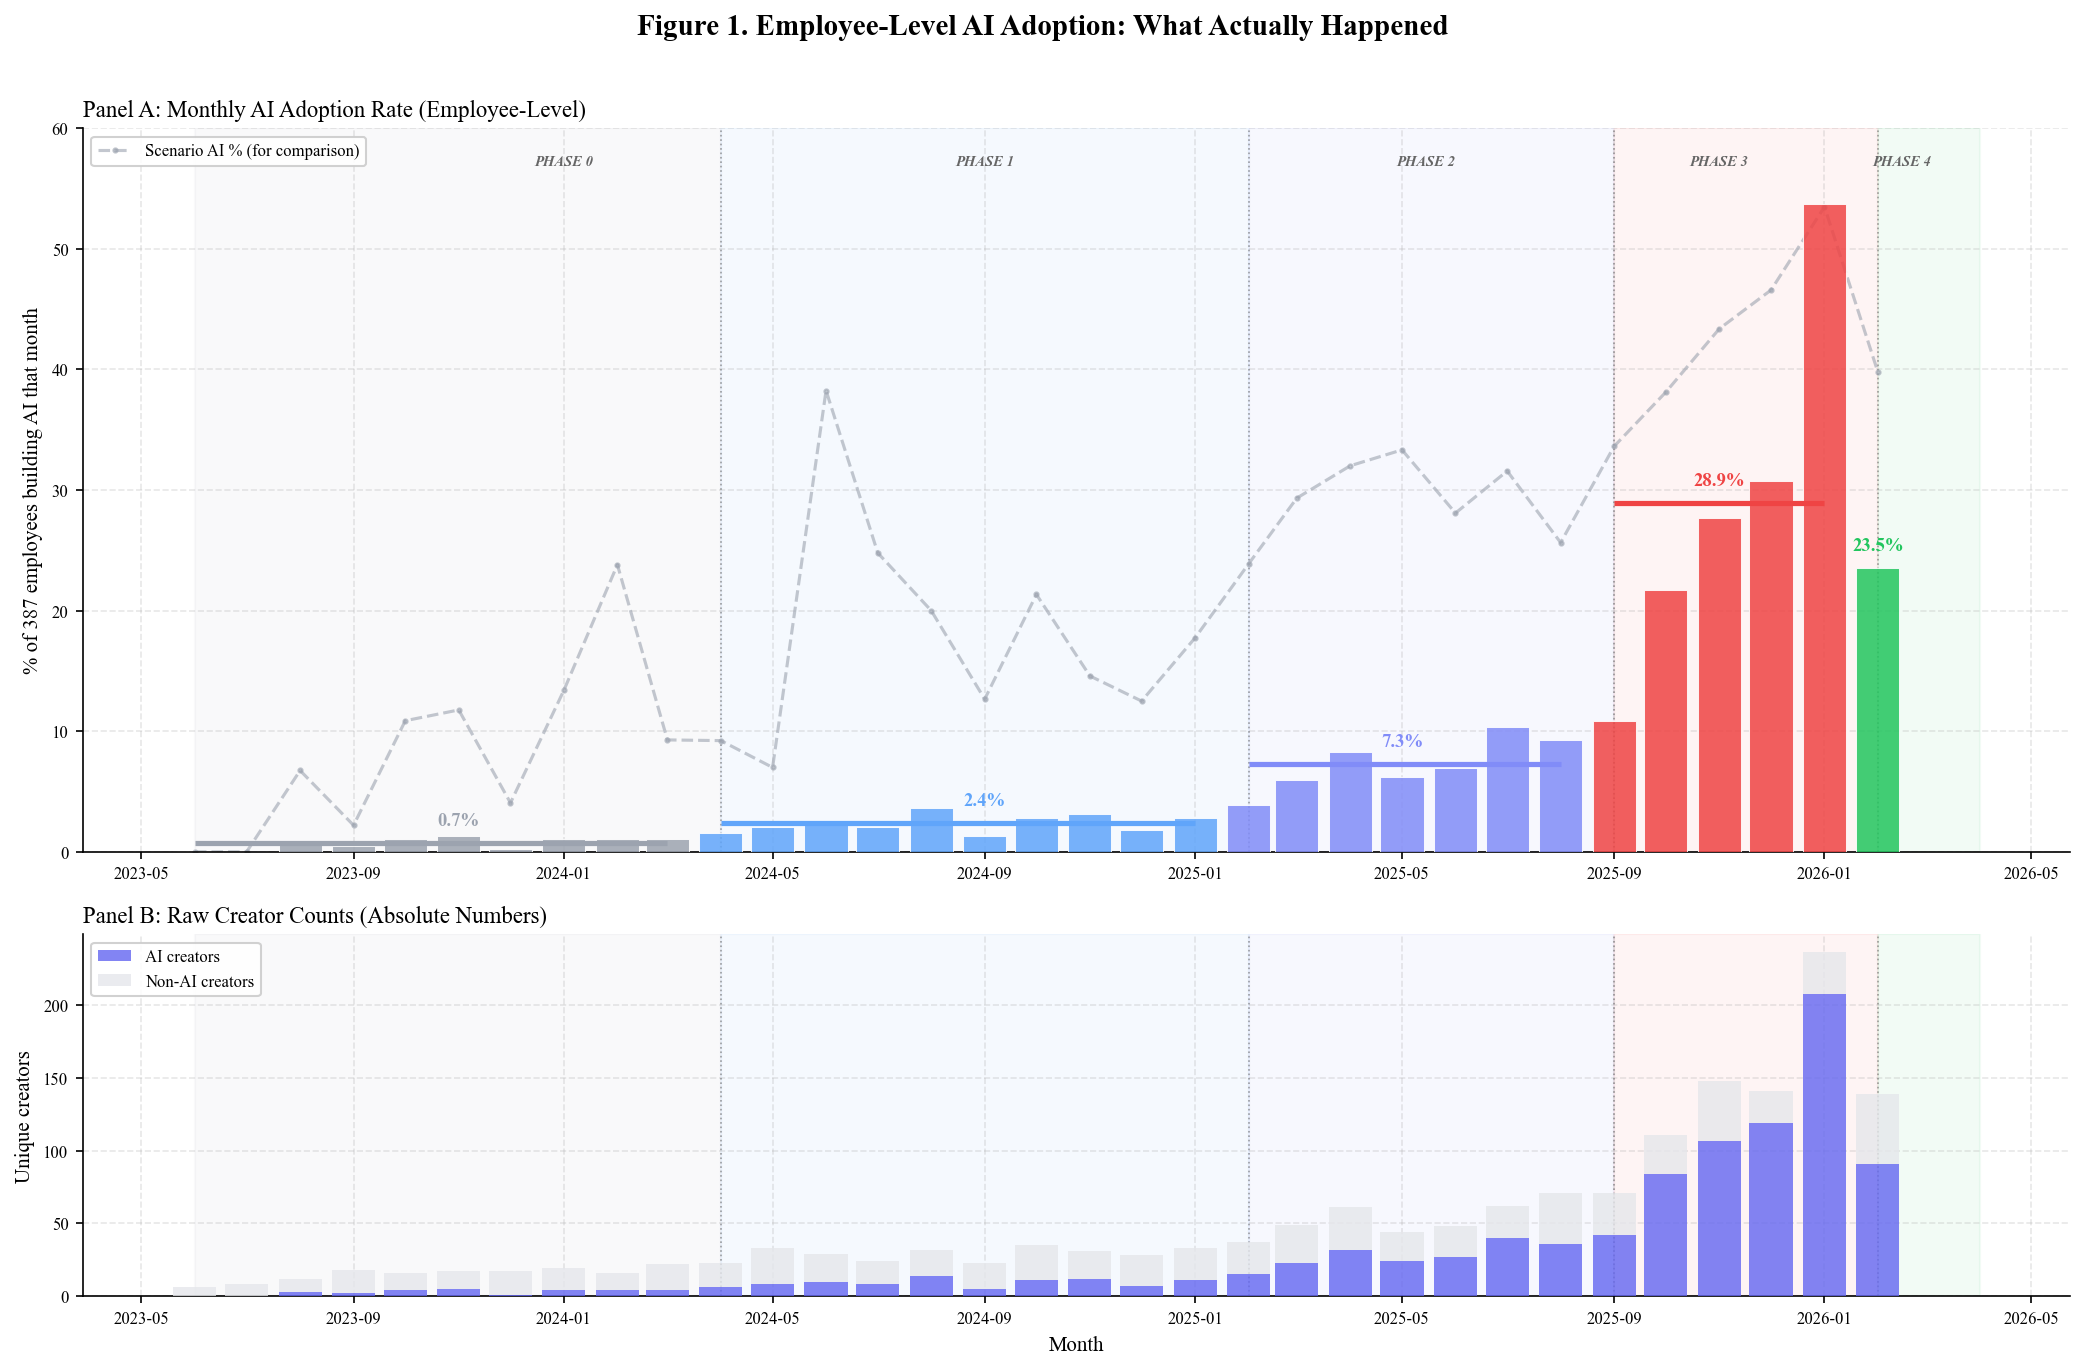


PHASE SUMMARY (Employee-Level Adoption)
Phase 0       |  mean:   0.7%  |  range:  0.0%– 1.3%  |  months: 10  |  scenario AI%:   8.2%
Phase 1       |  mean:   2.4%  |  range:  1.3%– 3.6%  |  months: 10  |  scenario AI%:  17.8%
Phase 2       |  mean:   7.3%  |  range:  3.9%–10.3%  |  months: 7  |  scenario AI%:  29.1%
Phase 3       |  mean:  28.9%  |  range: 10.9%–53.7%  |  months: 5  |  scenario AI%:  43.0%
Phase 4       |  mean:  23.5%  |  range: 23.5%–23.5%  |  months: 1  |  scenario AI%:  39.8%

KEY COMPARISON: Employee adoption vs Scenario AI%
The scenario metric consistently overstates adoption because prolific builders skew it.


In [13]:
# ============================================================
# FINDING 1: Employee-level monthly adoption by phase
# ============================================================

# Monthly employee-level metrics
monthly_emp = valid.groupby('created_month').agg(
    total_scenarios  = ('ID_scenario', 'count'),
    ai_scenarios     = ('is_ai_or_agent', 'sum'),
    agent_scenarios  = ('is_agent', 'sum'),
    total_creators   = ('CreatedBy', 'nunique'),
).reset_index()

# AI creators per month (unique people who built AI)
ai_only = valid[valid['is_ai_or_agent']].copy()
ai_creators_monthly = ai_only.groupby('created_month')['CreatedBy'].nunique().reset_index()
ai_creators_monthly.columns = ['created_month', 'ai_creators']

monthly_emp = monthly_emp.merge(ai_creators_monthly, on='created_month', how='left')
monthly_emp['ai_creators'] = monthly_emp['ai_creators'].fillna(0).astype(int)

# The two metrics
monthly_emp['employee_adoption_pct'] = monthly_emp['ai_creators'] / HEADCOUNT * 100
monthly_emp['scenario_ai_pct']       = monthly_emp['ai_scenarios'] / monthly_emp['total_scenarios'] * 100
monthly_emp['phase'] = monthly_emp['created_month'].apply(assign_phase)

# Filter to meaningful months
m = monthly_emp[(monthly_emp['total_scenarios'] >= 10) &
                (monthly_emp['created_month'] < pd.Timestamp('2026-03-01'))].copy()

# === FIGURE 1: The Core Chart ===
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle('Figure 1. Employee-Level AI Adoption: What Actually Happened',
             fontsize=14, fontweight='bold', y=1.01)

x = m['created_month']

# Panel A: Employee adoption rate
ax = axes[0]
shade_phases(ax)
bars = ax.bar(x, m['employee_adoption_pct'], width=25,
              color=[PHASE_COLORS.get(p, '#ccc') for p in m['phase']],
              edgecolor='white', linewidth=0.5, zorder=3, alpha=0.85)
ax.plot(x, m['scenario_ai_pct'], color='#9ca3af', linewidth=1.5, ls='--',
        marker='.', markersize=4, label='Scenario AI % (for comparison)', zorder=2, alpha=0.6)

# Phase means
for phase_name in ['Phase 0','Phase 1','Phase 2','Phase 3','Phase 4']:
    pm = m[m['phase'] == phase_name]
    if len(pm) > 0:
        mean_val = pm['employee_adoption_pct'].mean()
        ax.hlines(mean_val, pm['created_month'].min(), pm['created_month'].max(),
                  colors=PHASE_COLORS[phase_name], linewidth=2.5, zorder=4)
        ax.text(pm['created_month'].iloc[len(pm)//2], mean_val + 1.5,
                f'{mean_val:.1f}%', fontsize=9, fontweight='bold',
                color=PHASE_COLORS[phase_name], ha='center', zorder=5)

ax.set_ylabel(f'% of {HEADCOUNT} employees building AI that month')
ax.set_title('Panel A: Monthly AI Adoption Rate (Employee-Level)', fontsize=11, loc='left')
ax.legend(loc='upper left', framealpha=0.9)
ax.set_ylim(0, 60)

# Phase labels at top
for label, xpos in [('PHASE 0','2024-01-01'),('PHASE 1','2024-09-01'),
                     ('PHASE 2','2025-05-15'),('PHASE 3','2025-11-01'),('PHASE 4','2026-02-15')]:
    ax.text(pd.Timestamp(xpos), 57, label, fontsize=7, color='#666',
            ha='center', fontweight='bold', fontstyle='italic')

# Panel B: Raw numbers
ax = axes[1]
shade_phases(ax)
ax.bar(x, m['ai_creators'], width=25, color='#6366f1', alpha=0.8, label='AI creators', zorder=3)
ax.bar(x, m['total_creators'] - m['ai_creators'], width=25, bottom=m['ai_creators'],
       color='#e5e7eb', alpha=0.8, label='Non-AI creators', zorder=3)
ax.set_ylabel('Unique creators')
ax.set_title('Panel B: Raw Creator Counts (Absolute Numbers)', fontsize=11, loc='left')
ax.legend(loc='upper left', framealpha=0.9)
ax.set_xlabel('Month')

plt.tight_layout()
plt.savefig('fig1_employee_adoption_arc.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
print('\n' + '='*80)
print('PHASE SUMMARY (Employee-Level Adoption)')
print('='*80)
for phase in ['Phase 0','Phase 1','Phase 2','Phase 3','Phase 4']:
    pm = m[m['phase'] == phase]
    if len(pm) > 0:
        print(f'{phase:12s}  |  mean: {pm["employee_adoption_pct"].mean():5.1f}%  |  '
              f'range: {pm["employee_adoption_pct"].min():4.1f}%–{pm["employee_adoption_pct"].max():4.1f}%  |  '
              f'months: {len(pm)}  |  '
              f'scenario AI%: {pm["scenario_ai_pct"].mean():5.1f}%')
print()
print('KEY COMPARISON: Employee adoption vs Scenario AI%')
print('The scenario metric consistently overstates adoption because prolific builders skew it.')

### Finding 2: Phase 3 as a Structural Discontinuity

The transition from Phase 2 to Phase 3 was not a gradual acceleration. The data suggest a structural break in the adoption time series.


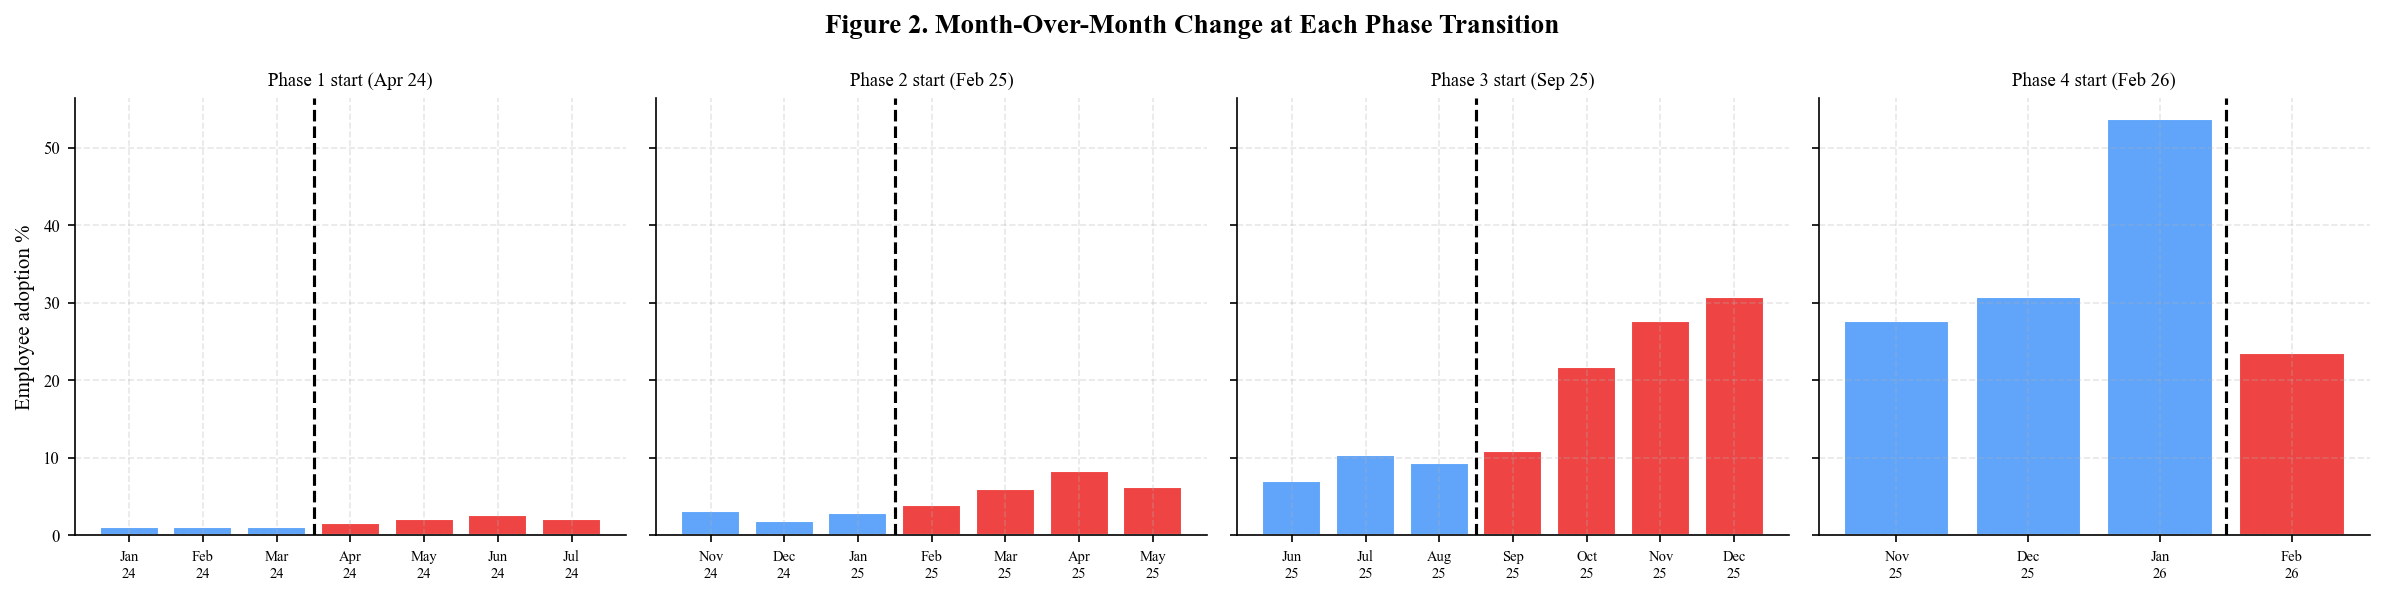

Phase 2 → Phase 3 comparison:
  Phase 2 mean: 7.3%  (n=7 months)
  Phase 3 mean: 28.9%  (n=5 months)
  Difference:   +21.7pp
  t-statistic:  -3.04
  p-value:      0.0369
  Cohen's d:    2.14 (large)

All phase-to-phase jumps:
  Phase 0 (0.7%) → Phase 1 (2.4%): 3.4x  (+1.7pp)
  Phase 1 (2.4%) → Phase 2 (7.3%): 3.1x  (+4.9pp)
  Phase 2 (7.3%) → Phase 3 (28.9%): 4.0x  (+21.7pp)
  Phase 3 (28.9%) → Phase 4 (23.5%): 0.8x  (-5.4pp)


In [14]:
# ============================================================
# FINDING 2: Structural break analysis
# ============================================================

# Month-over-month change at each phase boundary
m_sorted = m.sort_values('created_month').copy()
m_sorted['emp_pct_change'] = m_sorted['employee_adoption_pct'].diff()

# Get the months around each transition
transitions = {
    'Phase 1 start (Apr 24)': ('2024-03-01', '2024-04-01', '2024-05-01'),
    'Phase 2 start (Feb 25)': ('2025-01-01', '2025-02-01', '2025-03-01'),
    'Phase 3 start (Sep 25)': ('2025-08-01', '2025-09-01', '2025-10-01'),
    'Phase 4 start (Feb 26)': ('2026-01-01', '2026-02-01', None),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig.suptitle('Figure 2. Month-Over-Month Change at Each Phase Transition',
             fontsize=13, fontweight='bold')

for idx, (label, (before, boundary, after)) in enumerate(transitions.items()):
    ax = axes[idx]
    before_ts = pd.Timestamp(before)
    boundary_ts = pd.Timestamp(boundary)

    # Get 3 months before and after
    window = m_sorted[(m_sorted['created_month'] >= before_ts - pd.DateOffset(months=2)) &
                       (m_sorted['created_month'] <= (pd.Timestamp(after) + pd.DateOffset(months=2) if after else boundary_ts + pd.DateOffset(months=1)))].copy()

    if len(window) > 0:
        colors = ['#60a5fa' if t < boundary_ts else '#ef4444' for t in window['created_month']]
        ax.bar(range(len(window)), window['employee_adoption_pct'], color=colors, edgecolor='white')
        ax.set_xticks(range(len(window)))
        ax.set_xticklabels([t.strftime('%b\n%y') for t in window['created_month']], fontsize=7)
        ax.axvline(x=len(window[window['created_month'] < boundary_ts]) - 0.5,
                   color='black', ls='--', lw=1.5)
    ax.set_title(label, fontsize=9)
    if idx == 0:
        ax.set_ylabel('Employee adoption %')

plt.tight_layout()
plt.savefig('fig2_phase_transitions.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical test: is Phase 3 a structural break?
p1_vals = m[m['phase'] == 'Phase 1']['employee_adoption_pct'].values
p2_vals = m[m['phase'] == 'Phase 2']['employee_adoption_pct'].values
p3_vals = m[m['phase'] == 'Phase 3']['employee_adoption_pct'].values

if len(p2_vals) > 1 and len(p3_vals) > 1:
    t_stat, p_val = stats.ttest_ind(p2_vals, p3_vals, equal_var=False)
    cohens_d = (p3_vals.mean() - p2_vals.mean()) / np.sqrt((p2_vals.std()**2 + p3_vals.std()**2)/2)
    print(f'Phase 2 → Phase 3 comparison:')
    print(f'  Phase 2 mean: {p2_vals.mean():.1f}%  (n={len(p2_vals)} months)')
    print(f'  Phase 3 mean: {p3_vals.mean():.1f}%  (n={len(p3_vals)} months)')
    print(f'  Difference:   {p3_vals.mean() - p2_vals.mean():+.1f}pp')
    print(f'  t-statistic:  {t_stat:.2f}')
    print(f'  p-value:      {p_val:.4f}')
    print(f"  Cohen's d:    {cohens_d:.2f} ({'large' if abs(cohens_d) > 0.8 else 'medium' if abs(cohens_d) > 0.5 else 'small'})")
else:
    print('Insufficient data for Phase 2 → 3 t-test')

# ALL phase comparisons
print('\nAll phase-to-phase jumps:')
for p_from, p_to in [('Phase 0','Phase 1'),('Phase 1','Phase 2'),('Phase 2','Phase 3'),('Phase 3','Phase 4')]:
    v_from = m[m['phase'] == p_from]['employee_adoption_pct'].values
    v_to   = m[m['phase'] == p_to]['employee_adoption_pct'].values
    if len(v_from) > 0 and len(v_to) > 0:
        print(f'  {p_from} ({v_from.mean():.1f}%) → {p_to} ({v_to.mean():.1f}%): '
              f'{v_to.mean()/v_from.mean():.1f}x  ({v_to.mean()-v_from.mean():+.1f}pp)')

### Finding 3: Cumulative Reach — 86.8% of All Employees

Cumulative unique employees who created at least one AI-enabled scenario over the study period.

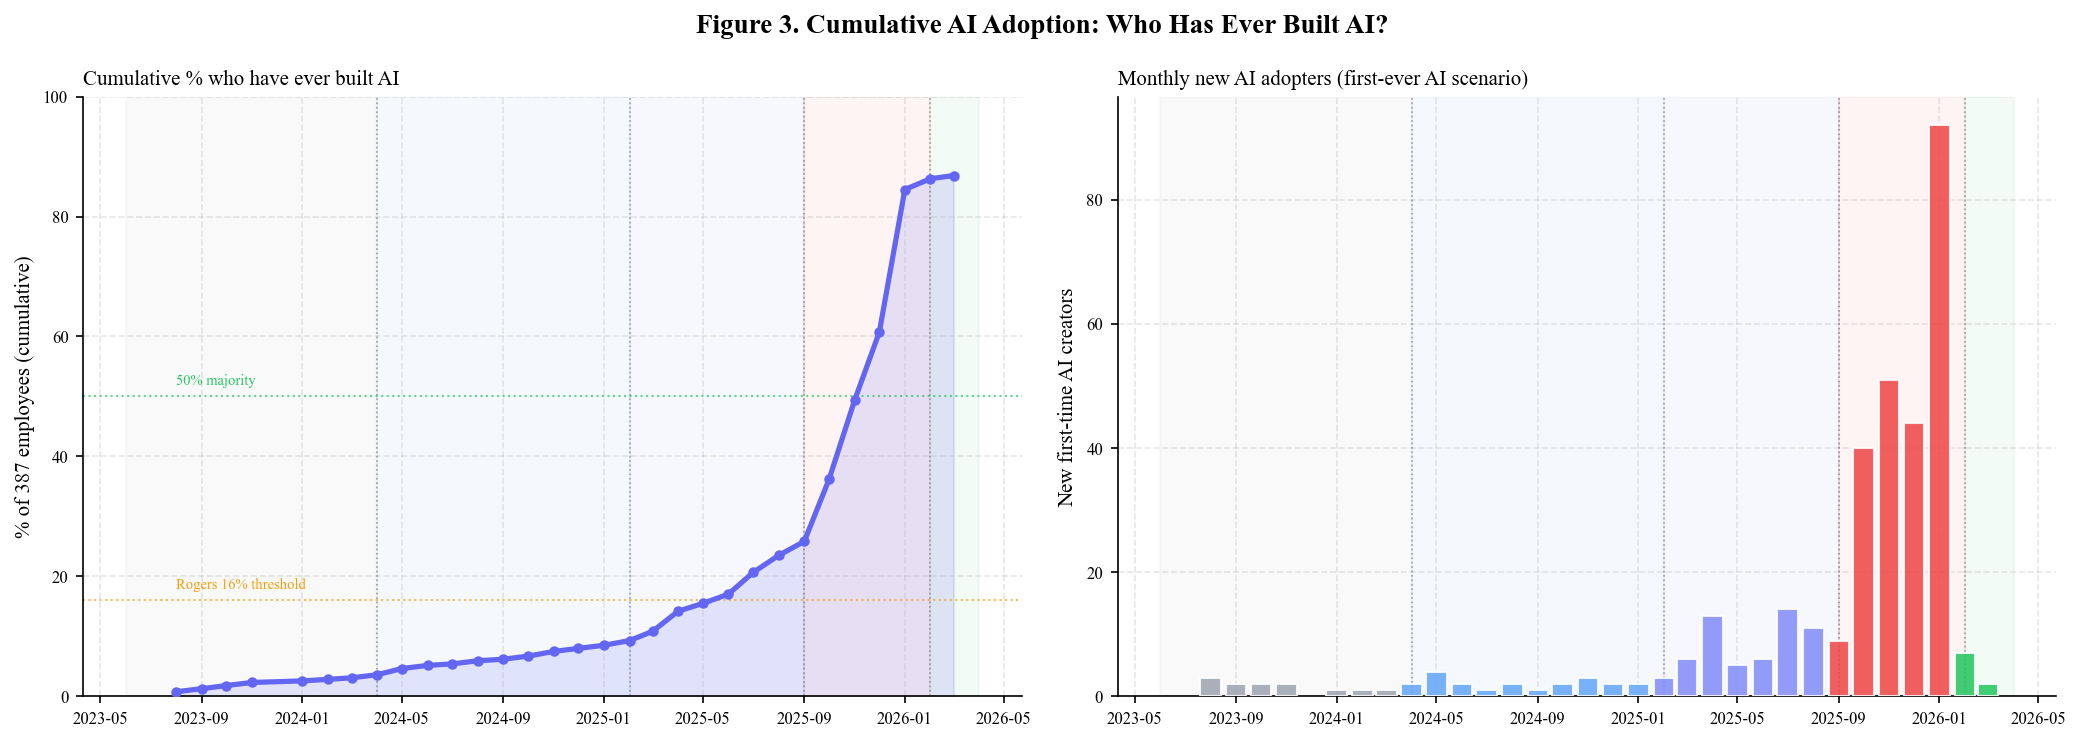

Total unique AI creators ever: 336 (86.8% of 387)

New AI creators by phase:
  Phase 0: 12 new creators (1.7/month)
  Phase 1: 21 new creators (2.1/month)
  Phase 2: 58 new creators (8.3/month)
  Phase 3: 236 new creators (47.2/month)
  Phase 4: 9 new creators (4.5/month)

Crossed 16% in Jun 2025 (Phase 2)

Crossed 25% in Sep 2025 (Phase 3)

Crossed 50% in Dec 2025 (Phase 3)

Crossed 75% in Jan 2026 (Phase 3)


In [15]:
# ============================================================
# FINDING 3: Cumulative S-curve
# ============================================================

# Track first AI scenario for each creator
first_ai = ai_only.groupby('CreatedBy')['created_date'].min().reset_index()
first_ai.columns = ['creator', 'first_ai_date']
first_ai['first_ai_month'] = first_ai['first_ai_date'].dt.to_period('M').dt.to_timestamp()

# Cumulative new AI creators per month
new_per_month = first_ai.groupby('first_ai_month').size().reset_index(name='new_ai_creators')
new_per_month = new_per_month.sort_values('first_ai_month')
new_per_month['cumulative'] = new_per_month['new_ai_creators'].cumsum()
new_per_month['cum_pct'] = new_per_month['cumulative'] / HEADCOUNT * 100
new_per_month['phase'] = new_per_month['first_ai_month'].apply(assign_phase)

# Figure 3: S-curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 3. Cumulative AI Adoption: Who Has Ever Built AI?',
             fontsize=13, fontweight='bold')

# Left: Cumulative %
shade_phases(ax1)
ax1.plot(new_per_month['first_ai_month'], new_per_month['cum_pct'],
         color='#6366f1', linewidth=2.5, marker='o', markersize=4, zorder=4)
ax1.fill_between(new_per_month['first_ai_month'], 0, new_per_month['cum_pct'],
                 alpha=0.15, color='#6366f1')
ax1.axhline(16, color='#f59e0b', ls=':', lw=1, alpha=0.7)
ax1.text(pd.Timestamp('2023-08-01'), 18, 'Rogers 16% threshold', fontsize=7, color='#f59e0b')
ax1.axhline(50, color='#22c55e', ls=':', lw=1, alpha=0.7)
ax1.text(pd.Timestamp('2023-08-01'), 52, '50% majority', fontsize=7, color='#22c55e')
ax1.set_ylabel(f'% of {HEADCOUNT} employees (cumulative)')
ax1.set_title('Cumulative % who have ever built AI', fontsize=10, loc='left')
ax1.set_ylim(0, 100)

# Right: New AI creators per month
shade_phases(ax2)
ax2.bar(new_per_month['first_ai_month'], new_per_month['new_ai_creators'], width=25,
        color=[PHASE_COLORS.get(p, '#ccc') for p in new_per_month['phase']],
        edgecolor='white', alpha=0.85, zorder=3)
ax2.set_ylabel('New first-time AI creators')
ax2.set_title('Monthly new AI adopters (first-ever AI scenario)', fontsize=10, loc='left')

plt.tight_layout()
plt.savefig('fig3_cumulative_scurve.png', dpi=300, bbox_inches='tight')
plt.show()

# Key stats
total_ever = first_ai.shape[0]
print(f'Total unique AI creators ever: {total_ever} ({total_ever/HEADCOUNT*100:.1f}% of {HEADCOUNT})')
print(f'\nNew AI creators by phase:')
for phase in ['Phase 0','Phase 1','Phase 2','Phase 3','Phase 4']:
    pp = new_per_month[new_per_month['phase'] == phase]
    if len(pp) > 0:
        print(f'  {phase}: {pp["new_ai_creators"].sum()} new creators '
              f'({pp["new_ai_creators"].mean():.1f}/month)')

# When did we cross key thresholds?
for threshold in [16, 25, 50, 75]:
    crossed = new_per_month[new_per_month['cum_pct'] >= threshold]
    if len(crossed) > 0:
        when = crossed.iloc[0]
        print(f'\nCrossed {threshold}% in {when["first_ai_month"].strftime("%b %Y")} ({when["phase"]})')

### Finding 4: Post-Mandate Retention

A central question for mandated adoption: does the behaviour persist after the mandate is removed?


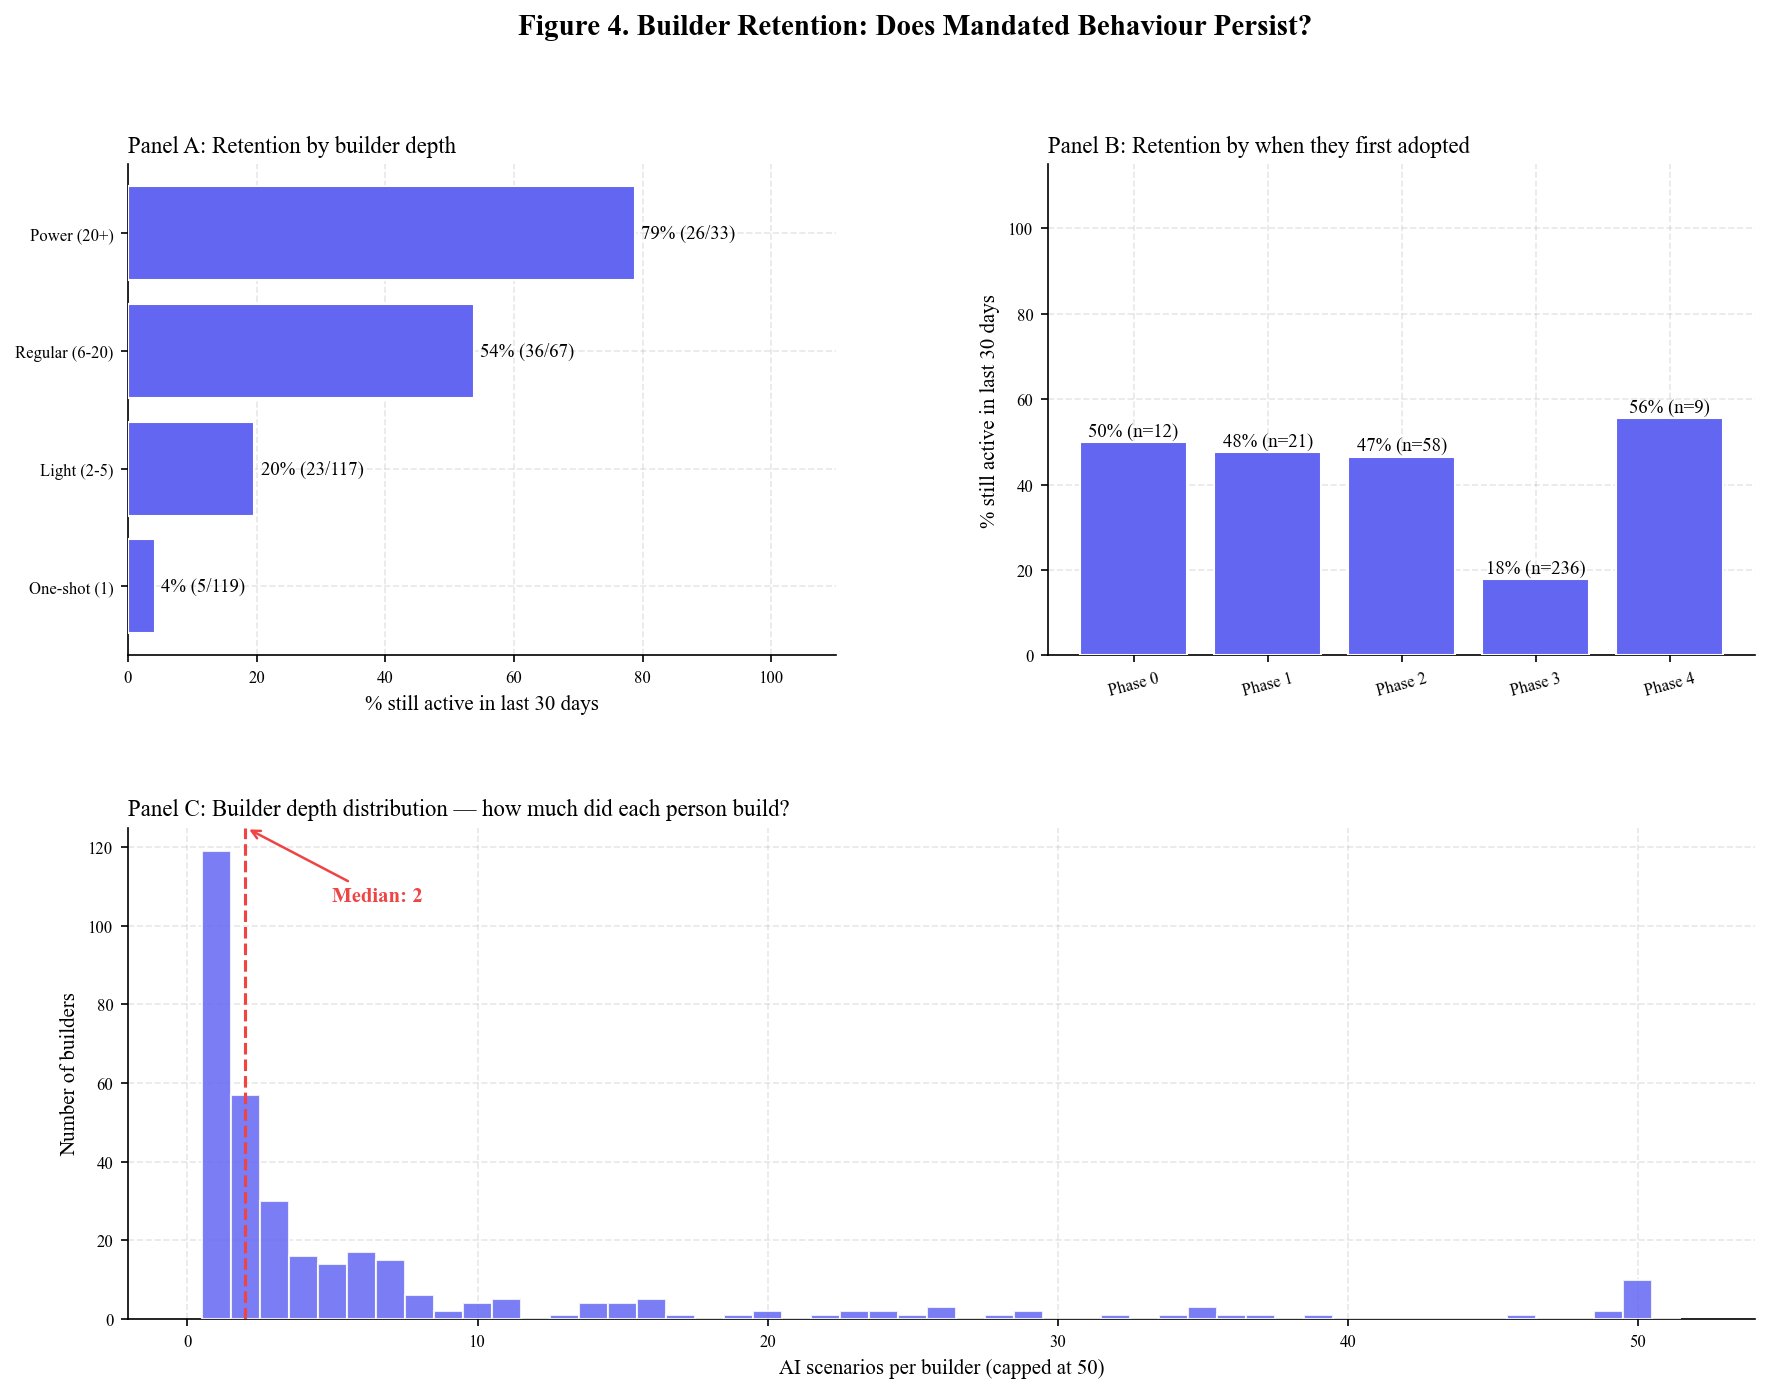


RETENTION SUMMARY:
  One-shot builders: 119 (4.2% retained)
  Multi-builders:    217 (39.2% retained)
  Gap:               9.3x

  Power builders (20+): 35 people
  They account for 1778 scenarios (62.4% of all AI scenarios)


In [16]:
# ============================================================
# FINDING 4: Retention analysis
# ============================================================

# Classify builders by depth
builder_stats = ai_only.groupby('CreatedBy').agg(
    total_ai     = ('ID_scenario', 'count'),
    first_ai     = ('created_date', 'min'),
    last_ai      = ('created_date', 'max'),
    n_months     = ('created_month', 'nunique'),
    n_depts      = ('dept_clean', 'nunique'),
).reset_index()

builder_stats['span_days'] = (builder_stats['last_ai'] - builder_stats['first_ai']).dt.days
builder_stats['first_phase'] = builder_stats['first_ai'].apply(assign_phase)

# Active in last 30 days (Feb 5 – Mar 7, 2026)
recent_cutoff = pd.Timestamp('2026-02-05')
recent_creators = set(ai_only[ai_only['created_date'] >= recent_cutoff]['CreatedBy'].unique())
builder_stats['recently_active'] = builder_stats['CreatedBy'].isin(recent_creators)

# Builder categories
builder_stats['builder_type'] = pd.cut(builder_stats['total_ai'],
                                        bins=[0, 1, 5, 20, 1000],
                                        labels=['One-shot (1)', 'Light (2-5)', 'Regular (6-20)', 'Power (20+)'])

# Figure 4: Retention — 2 rows: top row = panels A+B, bottom row = panel C full width
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Figure 4. Builder Retention: Does Mandated Behaviour Persist?',
             fontsize=14, fontweight='bold', y=0.98)

gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1], hspace=0.35, wspace=0.3)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

# --- Panel A: Retention by builder type ---
retention_by_type = builder_stats.groupby('builder_type').agg(
    count=('CreatedBy', 'count'),
    retained=('recently_active', 'sum')
).reset_index()
retention_by_type['retention_pct'] = retention_by_type['retained'] / retention_by_type['count'] * 100

BAR_COLOR = '#6366f1'
bars = ax_a.barh(retention_by_type['builder_type'].astype(str), retention_by_type['retention_pct'],
               color=BAR_COLOR, edgecolor='white', zorder=3)
for bar, row in zip(bars, retention_by_type.itertuples()):
    ax_a.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{row.retention_pct:.0f}% ({row.retained}/{row.count})',
            va='center', fontsize=9)
ax_a.set_xlabel('% still active in last 30 days')
ax_a.set_title('Panel A: Retention by builder depth', fontsize=11, loc='left')
ax_a.set_xlim(0, 110)

# --- Panel B: Retention by first-adoption phase ---
retention_by_phase = builder_stats.groupby('first_phase').agg(
    count=('CreatedBy', 'count'),
    retained=('recently_active', 'sum')
).reset_index()
retention_by_phase['retention_pct'] = retention_by_phase['retained'] / retention_by_phase['count'] * 100

bars = ax_b.bar(retention_by_phase['first_phase'], retention_by_phase['retention_pct'],
              color=BAR_COLOR, edgecolor='white', zorder=3)
for bar, row in zip(bars, retention_by_phase.itertuples()):
    ax_b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{row.retention_pct:.0f}% (n={row.count})', ha='center', fontsize=9)
ax_b.set_ylabel('% still active in last 30 days')
ax_b.set_title('Panel B: Retention by when they first adopted', fontsize=11, loc='left')
ax_b.set_ylim(0, 115)
ax_b.tick_params(axis='x', rotation=15)

# --- Panel C: Distribution of builder depth (full width) ---
bins = np.arange(0.5, 52.5, 1)
ax_c.hist(builder_stats['total_ai'].clip(upper=50), bins=bins, color=BAR_COLOR,
        edgecolor='white', alpha=0.85, zorder=3)
med = builder_stats['total_ai'].median()
ax_c.axvline(med, color='#ef4444', ls='--', lw=1.5, zorder=4)
ax_c.annotate(f'Median: {med:.0f}', xy=(med, ax_c.get_ylim()[1] if ax_c.get_ylim()[1] > 0 else 100),
              xytext=(med + 3, ax_c.get_ylim()[1]*0.85 if ax_c.get_ylim()[1] > 0 else 85),
              fontsize=10, color='#ef4444', fontweight='bold',
              arrowprops=dict(arrowstyle='->', color='#ef4444', lw=1.2))
ax_c.set_xlabel('AI scenarios per builder (capped at 50)')
ax_c.set_ylabel('Number of builders')
ax_c.set_title('Panel C: Builder depth distribution — how much did each person build?', fontsize=11, loc='left')

plt.savefig('fig4_retention.png', dpi=300, bbox_inches='tight')
plt.show()

# Key stats
multi = builder_stats[builder_stats['total_ai'] > 1]
oneshot = builder_stats[builder_stats['total_ai'] == 1]
print(f'\nRETENTION SUMMARY:')
print(f'  One-shot builders: {len(oneshot)} ({oneshot["recently_active"].mean()*100:.1f}% retained)')
print(f'  Multi-builders:    {len(multi)} ({multi["recently_active"].mean()*100:.1f}% retained)')
print(f'  Gap:               {multi["recently_active"].mean()/oneshot["recently_active"].mean():.1f}x')
print(f'\n  Power builders (20+): {len(builder_stats[builder_stats["total_ai"]>=20])} people')
print(f'  They account for {builder_stats[builder_stats["total_ai"]>=20]["total_ai"].sum()} scenarios '
      f'({builder_stats[builder_stats["total_ai"]>=20]["total_ai"].sum()/len(ai_only)*100:.1f}% of all AI scenarios)')

### Finding 5: Department-Level Heterogeneity

Identical tool access and a uniform mandate produced substantially different adoption rates across departments.


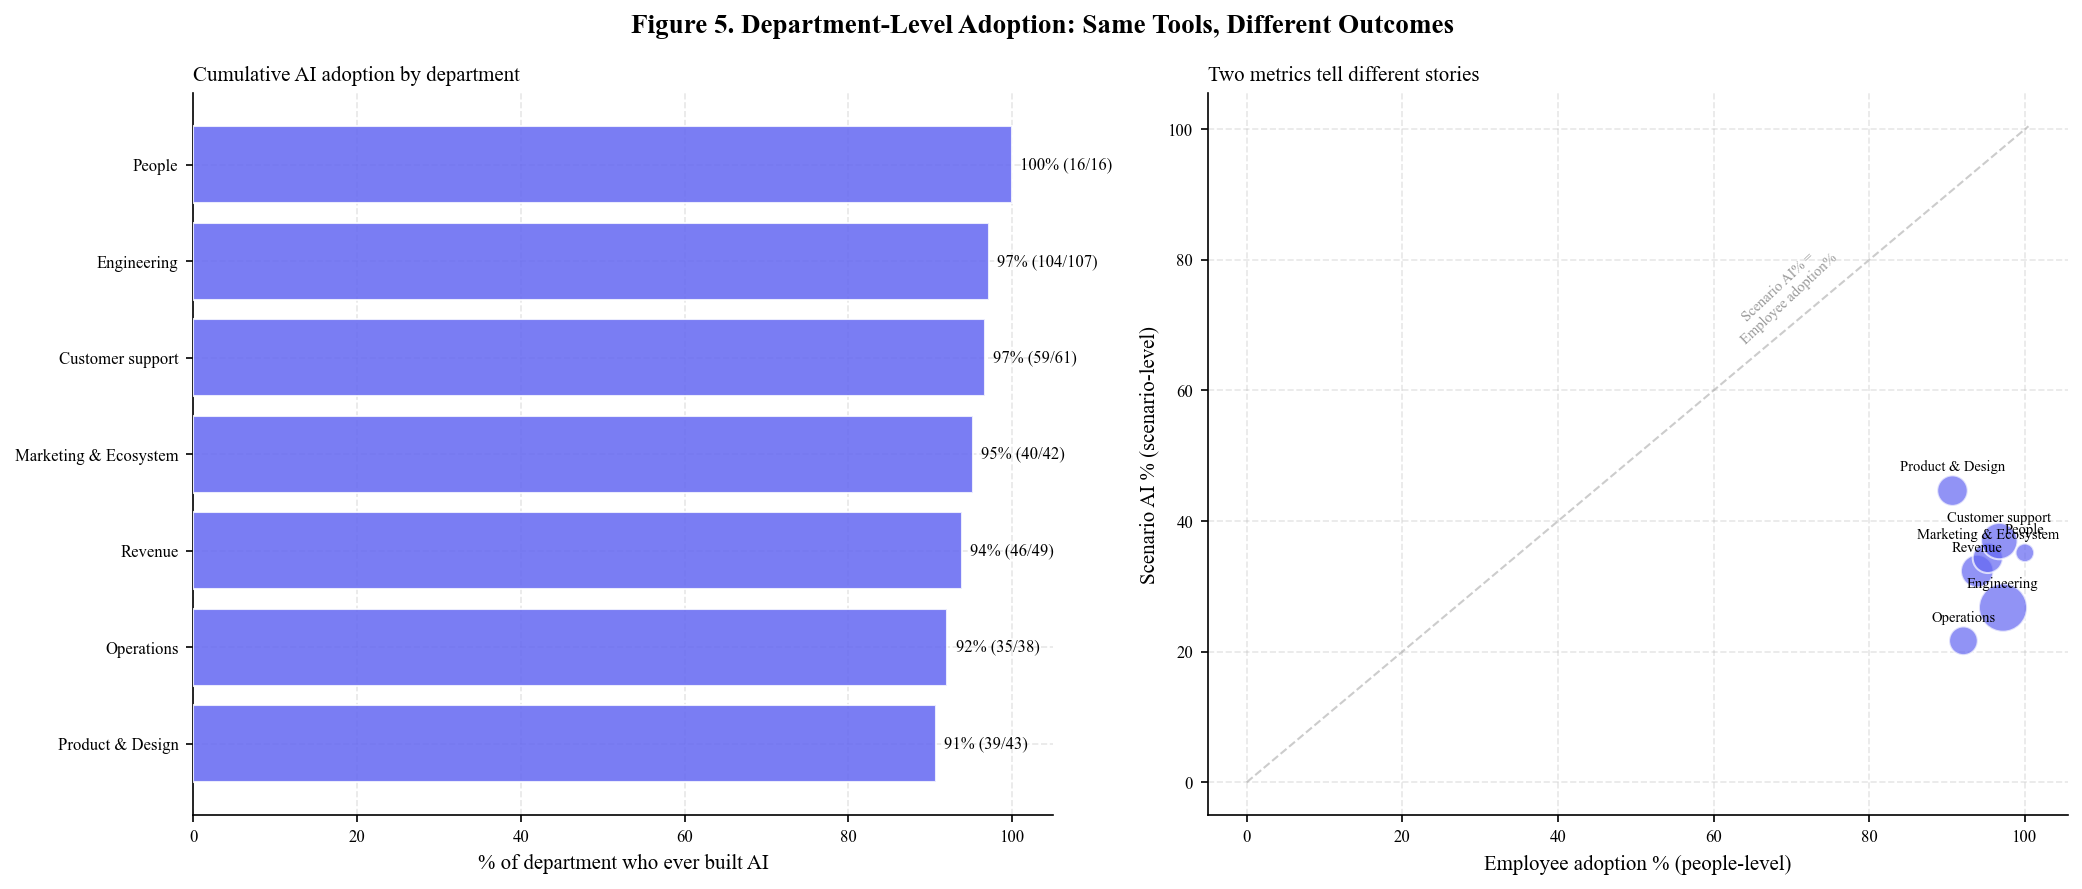

DEPARTMENT SUMMARY:
                 dept  total_people  ai_people  adoption_pct  scenario_ai_pct  p3_adoption_pct
     Product & Design            43         39          90.7             44.7             86.0
           Operations            38         35          92.1             21.7             73.7
              Revenue            49         46          93.9             32.3             85.7
Marketing & Ecosystem            42         40          95.2             34.4             92.9
     Customer support            61         59          96.7             36.9             82.0
          Engineering           107        104          97.2             26.7             94.4
               People            16         16         100.0             35.1            100.0

Spread: 100.0% / 90.7% = 1.1x


In [17]:
# ============================================================
# FINDING 5: Department-level heterogeneity (employee-level)
# ============================================================

# Department headcounts (estimated from data — unique creators as proxy for department size)
dept_all_creators = valid.groupby('dept_clean')['CreatedBy'].nunique().reset_index()
dept_all_creators.columns = ['dept', 'total_people']

# AI creators per department
dept_ai_creators = ai_only.groupby('dept_clean')['CreatedBy'].nunique().reset_index()
dept_ai_creators.columns = ['dept', 'ai_people']

dept_stats = dept_all_creators.merge(dept_ai_creators, on='dept', how='left')
dept_stats['ai_people'] = dept_stats['ai_people'].fillna(0).astype(int)
dept_stats['adoption_pct'] = dept_stats['ai_people'] / dept_stats['total_people'] * 100

# Per-department: scenario volume, AI%, agent%
dept_scenarios = valid.groupby('dept_clean').agg(
    scenarios=('ID_scenario', 'count'),
    ai_scenarios=('is_ai_or_agent', 'sum'),
    agent_scenarios=('is_agent', 'sum'),
).reset_index()
dept_scenarios.columns = ['dept', 'scenarios', 'ai_scenarios', 'agent_scenarios']
dept_scenarios['scenario_ai_pct'] = dept_scenarios['ai_scenarios'] / dept_scenarios['scenarios'] * 100

dept_stats = dept_stats.merge(dept_scenarios, on='dept')

# Phase 3 adoption per department (mandate period only)
p3_data = valid[(valid['phase'] == 'Phase 3') & valid['is_ai_or_agent']]
p3_dept = p3_data.groupby('dept_clean')['CreatedBy'].nunique().reset_index()
p3_dept.columns = ['dept', 'p3_ai_people']
dept_stats = dept_stats.merge(p3_dept, on='dept', how='left')
dept_stats['p3_ai_people'] = dept_stats['p3_ai_people'].fillna(0).astype(int)
dept_stats['p3_adoption_pct'] = dept_stats['p3_ai_people'] / dept_stats['total_people'] * 100

# Sort by adoption
dept_stats = dept_stats.sort_values('adoption_pct', ascending=True)

# Figure 5
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 5. Department-Level Adoption: Same Tools, Different Outcomes',
             fontsize=13, fontweight='bold')

# Panel A: Overall employee adoption by dept
ax = axes[0]
bars = ax.barh(dept_stats['dept'], dept_stats['adoption_pct'],
               color='#6366f1', alpha=0.85, edgecolor='white', zorder=3)
for bar, row in zip(bars, dept_stats.itertuples()):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{row.adoption_pct:.0f}% ({row.ai_people}/{row.total_people})',
            va='center', fontsize=8)
ax.set_xlabel('% of department who ever built AI')
ax.set_title('Cumulative AI adoption by department', fontsize=10, loc='left')

# Panel B: Scenario AI% vs Employee adoption %
ax = axes[1]
ax.scatter(dept_stats['adoption_pct'], dept_stats['scenario_ai_pct'],
           s=dept_stats['total_people']*5, alpha=0.7, color='#6366f1',
           edgecolor='white', linewidth=1, zorder=3)
for _, row in dept_stats.iterrows():
    ax.annotate(row['dept'], (row['adoption_pct'], row['scenario_ai_pct']),
                fontsize=7, ha='center', va='bottom', textcoords='offset points',
                xytext=(0, 8))
ax.set_xlabel('Employee adoption % (people-level)')
ax.set_ylabel('Scenario AI % (scenario-level)')
ax.set_title('Two metrics tell different stories', fontsize=10, loc='left')
# 45-degree line — compute correct display-space angle so label aligns with line
lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, color='#ccc', ls='--', lw=1, zorder=1)
fig.canvas.draw()  # force layout so transforms are current
p0 = ax.transData.transform((0, 0))
p1 = ax.transData.transform((1, 1))
angle_rad = np.arctan2(p1[1] - p0[1], p1[0] - p0[0])
angle_deg = np.degrees(angle_rad)
ax.text(lims[1]*0.7, lims[1]*0.73, 'Scenario AI% =\nEmployee adoption%',
        fontsize=7, color='#999', rotation=angle_deg, rotation_mode='anchor',
        ha='center', va='bottom')

plt.tight_layout()
plt.savefig('fig5_department_heterogeneity.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary
print('DEPARTMENT SUMMARY:')
print(dept_stats[['dept','total_people','ai_people','adoption_pct','scenario_ai_pct','p3_adoption_pct']].to_string(index=False, float_format='%.1f'))
spread = dept_stats['adoption_pct'].max() / dept_stats['adoption_pct'].min()
print(f'\nSpread: {dept_stats["adoption_pct"].max():.1f}% / {dept_stats["adoption_pct"].min():.1f}% = {spread:.1f}x')

## 4. Threats to Validity

The sequential, non-randomized design introduces several threats to internal and external validity.

### 4.1 Denominator Definition

We define the eligible population as 387 total employees — the 349 unique individuals who created at least one automation scenario during the study period plus 32 employees who did not build any workflows. This total-headcount denominator avoids inflating adoption rates by excluding non-participants.

Using only the 349 active scenario creators as the denominator would yield a cumulative AI adoption rate of approximately 96%, which overstates the breadth of adoption relative to the full workforce. The 387-person denominator produces a cumulative reach of 86.8%, which more accurately captures the proportion of the total workforce that adopted AI.

### 4.2 Compliance vs. Internalized Adoption

Phase 3 required employees to build AI scenarios. A meaningful proportion may have created minimal, low-value scenarios solely to satisfy the requirement. Scenario creation without sustained use or activation represents compliance rather than genuine adoption.

We examine this threat empirically:
- One-shot builders (created exactly 1 AI scenario, no subsequent activity) can be enumerated
- The active rate of mandate-era scenarios indicates whether they remain operational
- If compliance dominates, we should observe: elevated Phase 3 counts, low retention rates, and low scenario activation rates

### 4.3 Limited Phase 4 Observations

Phase 4 began in February 2026. We have one month of data. The observed rate of 23.5% may reflect Phase 3 momentum, novelty effects of the gamified intervention, or genuine internalization. These explanations cannot be distinguished with a single observation. Any inference about Phase 4 sustainability should be treated as preliminary.

### 4.4 Temporal Confounds

Each phase coincided with changes in the external environment:
- **AI model capability**: GPT-4o, Claude 3.5, and Gemini 1.5 launched during the study period. Phase 3 adoption may partly reflect improved AI capability rather than organizational intervention.
- **Market and social pressure**: Increasing industry-wide AI adoption created external motivation that is not measured in our data.
- **Learning effects**: By Phase 3, early adopters from Phase 1 had accumulated 18 months of experience. Peer demonstration effects may have contributed to adoption independently of the mandate.
- **Seasonality**: Phase 3 (September–January) includes Q4 planning cycles. Phase 1 spans the summer months. Workload variation is uncontrolled.


In [18]:
# ============================================================
# TESTING THE COUNTER-ARGUMENTS WITH DATA
# ============================================================

print('='*80)
print('COUNTER-ARGUMENT TEST 1: Is Phase 3 just checkbox compliance?')
print('='*80)

# Active rate by phase
phase_active = valid[valid['is_ai_or_agent']].groupby('phase').agg(
    total=('ID_scenario', 'count'),
    active=('is_active', 'sum'),
).reset_index()
phase_active['active_pct'] = phase_active['active'] / phase_active['total'] * 100
print('\nActive rate of AI scenarios by phase:')
print(phase_active.to_string(index=False, float_format='%.1f'))

# One-shot builders by phase
oneshot_by_phase = builder_stats[builder_stats['total_ai'] == 1].groupby('first_phase').size()
total_by_phase = builder_stats.groupby('first_phase').size()
oneshot_pct = (oneshot_by_phase / total_by_phase * 100).reset_index()
oneshot_pct.columns = ['phase', 'oneshot_pct']
print('\nOne-shot builder % by first-adoption phase:')
for _, row in oneshot_pct.iterrows():
    total = total_by_phase.get(row['phase'], 0)
    oneshots = oneshot_by_phase.get(row['phase'], 0)
    print(f'  {row["phase"]}: {row["oneshot_pct"]:.1f}% one-shot ({oneshots}/{total})')

print()
print('='*80)
print('COUNTER-ARGUMENT TEST 2: Are mandate-era scenarios actually running?')
print('='*80)

# Scenarios built during Phase 3, still active?
p3_scenarios = valid[(valid['phase'] == 'Phase 3') & valid['is_ai_or_agent']]
p2_scenarios = valid[(valid['phase'] == 'Phase 2') & valid['is_ai_or_agent']]
p1_scenarios = valid[(valid['phase'] == 'Phase 1') & valid['is_ai_or_agent']]

print(f'Phase 1 AI scenarios still active: {p1_scenarios["is_active"].mean()*100:.1f}% ({p1_scenarios["is_active"].sum()}/{len(p1_scenarios)})')
print(f'Phase 2 AI scenarios still active: {p2_scenarios["is_active"].mean()*100:.1f}% ({p2_scenarios["is_active"].sum()}/{len(p2_scenarios)})')
print(f'Phase 3 AI scenarios still active: {p3_scenarios["is_active"].mean()*100:.1f}% ({p3_scenarios["is_active"].sum()}/{len(p3_scenarios)})')

print()
print('='*80)
print('COUNTER-ARGUMENT TEST 3: Power law concentration')
print('='*80)

# What % of AI scenarios come from top 10% of builders?
top_10_pct = int(len(builder_stats) * 0.1)
top_builders = builder_stats.nlargest(top_10_pct, 'total_ai')
print(f'Top 10% of builders ({top_10_pct} people) account for:')
print(f'  {top_builders["total_ai"].sum()} of {builder_stats["total_ai"].sum()} AI scenarios '
      f'({top_builders["total_ai"].sum()/builder_stats["total_ai"].sum()*100:.1f}%)')
print(f'\nThis is why scenario-level metrics overstate adoption.')

# Gini coefficient of builder output
sorted_output = np.sort(builder_stats['total_ai'].values)
n = len(sorted_output)
cum_output = np.cumsum(sorted_output) / sorted_output.sum()
cum_pop = np.arange(1, n+1) / n
gini = 1 - 2 * np.trapz(cum_output, cum_pop)
print(f'\nGini coefficient of AI scenario production: {gini:.3f}')
print(f'(0 = perfectly equal, 1 = one person built everything)')
print(f'This is {"highly concentrated" if gini > 0.6 else "moderately concentrated" if gini > 0.4 else "relatively dispersed"}.')

COUNTER-ARGUMENT TEST 1: Is Phase 3 just checkbox compliance?

Active rate of AI scenarios by phase:
  phase  total  active  active_pct
Phase 0     73      13        17.8
Phase 1    259      25         9.7
Phase 2    526     107        20.3
Phase 3   1625     531        32.7
Phase 4    365      96        26.3

One-shot builder % by first-adoption phase:
  Phase 0: nan% one-shot (0/12)
  Phase 1: 4.8% one-shot (1/21)
  Phase 2: 12.1% one-shot (7/58)
  Phase 3: 43.2% one-shot (102/236)
  Phase 4: 100.0% one-shot (9/9)

COUNTER-ARGUMENT TEST 2: Are mandate-era scenarios actually running?
Phase 1 AI scenarios still active: 9.7% (25/259)
Phase 2 AI scenarios still active: 20.3% (107/526)
Phase 3 AI scenarios still active: 32.7% (531/1625)

COUNTER-ARGUMENT TEST 3: Power law concentration
Top 10% of builders (33 people) account for:
  1738 of 2848 AI scenarios (61.0%)

This is why scenario-level metrics overstate adoption.

Gini coefficient of AI scenario production: 0.708
(0 = perfectly equ

### Counterfactual: What If We Had Continued at Pre-Mandate (Phase 2) Growth Rates?

Phase 3's mandate compressed adoption dramatically. But what if the mandate had never happened and the organization had continued with Phase 2's structural enablement approach? How long would it have taken to reach the same cumulative adoption level?

This projection uses two models:
1. **Linear extrapolation**: Constant rate of ~8.3 new adopters/month (Phase 2 mean)
2. **Logistic model**: Accounts for saturation — the shrinking pool of non-adopters slows growth over time

Both models start from the actual cumulative adoption at the end of Phase 2 (91 employees, 23.5%) and project forward.

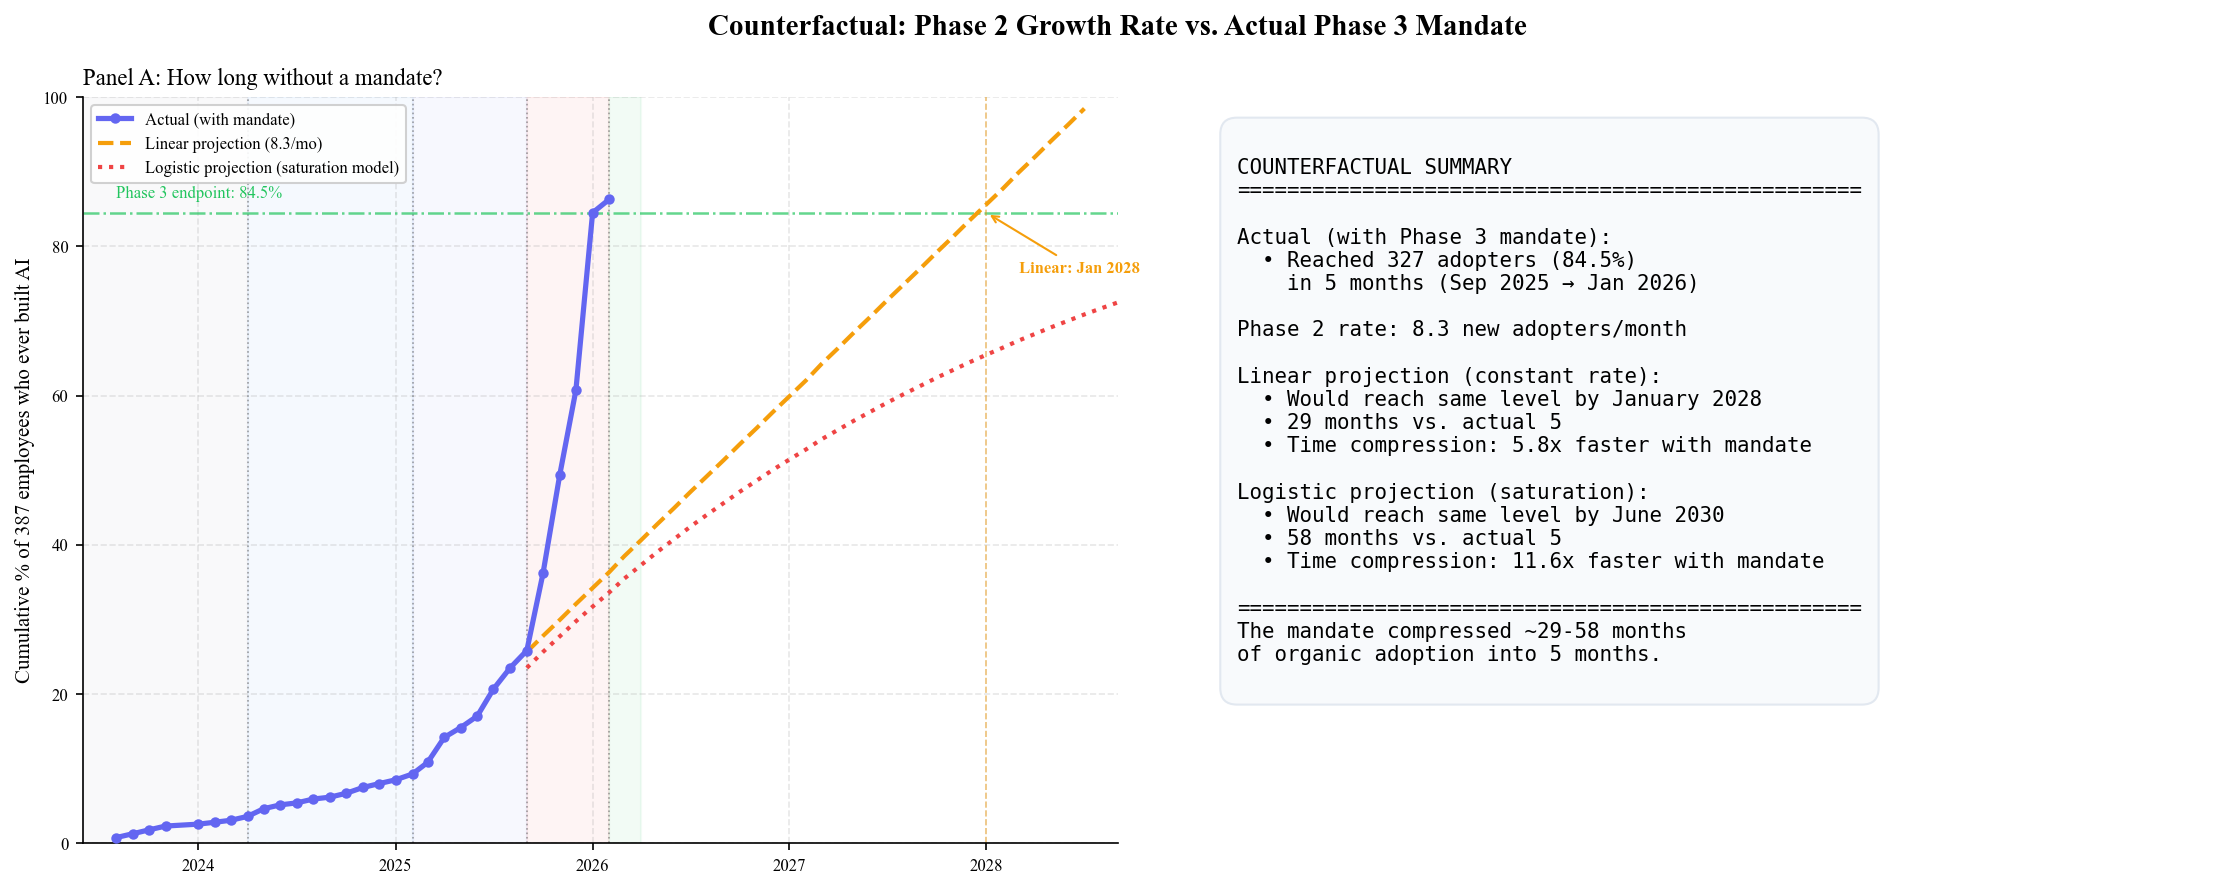

COUNTERFACTUAL PROJECTION RESULTS
Phase 2 mean new adopters/month:  8.3
Cumulative at end of Phase 2:     91 (23.5%)
Cumulative at end of Phase 3:     327 (84.5%)
Gap closed by mandate:            236 adopters
Actual time (Phase 3):            5 months
Linear projection:                29 months → Jan 2028
Logistic projection:              58 months → Jun 2030

The mandate bought ~38 months of acceleration.
Without it, 84.5% cumulative reach was ~2-3 years away.


In [19]:
# ============================================================
# COUNTERFACTUAL: Phase 2 growth rate extrapolated forward
# ============================================================

# --- Actual data: cumulative new AI adopters by month ---
first_ai = ai_only.groupby('CreatedBy')['created_date'].min().reset_index()
first_ai.columns = ['creator', 'first_ai_date']
first_ai['first_ai_month'] = first_ai['first_ai_date'].dt.to_period('M').dt.to_timestamp()

new_per_month = first_ai.groupby('first_ai_month').size().reset_index(name='new_ai_creators')
new_per_month = new_per_month.sort_values('first_ai_month')
new_per_month['cumulative'] = new_per_month['new_ai_creators'].cumsum()
new_per_month['cum_pct'] = new_per_month['cumulative'] / HEADCOUNT * 100
new_per_month['phase'] = new_per_month['first_ai_month'].apply(assign_phase)

# --- Phase 2 parameters ---
p2_data = new_per_month[new_per_month['phase'] == 'Phase 2']
p2_mean_new_per_month = p2_data['new_ai_creators'].mean()
cum_end_p2 = new_per_month[new_per_month['first_ai_month'] <= pd.Timestamp('2025-08-01')]['cumulative'].max()
cum_end_p3 = new_per_month[new_per_month['first_ai_month'] <= pd.Timestamp('2026-01-01')]['cumulative'].max()
phase2_end = pd.Timestamp('2025-08-01')

# --- Model 1: Linear extrapolation (constant rate) ---
months_linear = int(np.ceil((cum_end_p3 - cum_end_p2) / p2_mean_new_per_month))
linear_months = pd.date_range(start='2025-09-01', periods=months_linear + 6, freq='MS')
linear_cum = [cum_end_p2 + p2_mean_new_per_month * (i + 1) for i in range(len(linear_months))]
linear_cum = np.minimum(linear_cum, HEADCOUNT)  # cap at headcount

# --- Model 2: Logistic / saturation model ---
# Phase 2 adoption rate as fraction of REMAINING non-adopters
remaining_at_p2_end = HEADCOUNT - cum_end_p2
p2_adoption_frac_of_remaining = p2_mean_new_per_month / remaining_at_p2_end

logistic_cum = [cum_end_p2]
for i in range(60):  # project 60 months
    remaining = HEADCOUNT - logistic_cum[-1]
    new_adopters = remaining * p2_adoption_frac_of_remaining
    logistic_cum.append(min(logistic_cum[-1] + new_adopters, HEADCOUNT))
logistic_months = pd.date_range(start='2025-09-01', periods=61, freq='MS')

# --- Find when each model reaches Phase 3 cumulative level ---
linear_cross_idx = next((i for i, c in enumerate(linear_cum) if c >= cum_end_p3), None)
logistic_cross_idx = next((i for i, c in enumerate(logistic_cum) if c >= cum_end_p3), None)

linear_cross_date = linear_months[linear_cross_idx] if linear_cross_idx is not None else None
logistic_cross_date = logistic_months[logistic_cross_idx] if logistic_cross_idx is not None else None

# --- FIGURE: Counterfactual projection ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Counterfactual: Phase 2 Growth Rate vs. Actual Phase 3 Mandate',
             fontsize=14, fontweight='bold')

# --- Panel A: Cumulative adoption curves ---
ax = ax1
shade_phases(ax)

# Actual data
actual = new_per_month[new_per_month['first_ai_month'] <= pd.Timestamp('2026-02-01')]
ax.plot(actual['first_ai_month'], actual['cum_pct'], color='#6366f1', linewidth=2.5,
        marker='o', markersize=4, label='Actual (with mandate)', zorder=5)

# Linear projection
ax.plot(linear_months[:40], np.array(linear_cum[:40]) / HEADCOUNT * 100,
        color='#f59e0b', linewidth=2, ls='--', label=f'Linear projection ({p2_mean_new_per_month:.1f}/mo)', zorder=4)

# Logistic projection
ax.plot(logistic_months[:40], np.array(logistic_cum[:40]) / HEADCOUNT * 100,
        color='#ef4444', linewidth=2, ls=':', label=f'Logistic projection (saturation model)', zorder=4)

# Mark Phase 3 target level
ax.axhline(cum_end_p3 / HEADCOUNT * 100, color='#22c55e', ls='-.', lw=1.2, alpha=0.7)
ax.text(pd.Timestamp('2023-08-01'), cum_end_p3 / HEADCOUNT * 100 + 2,
        f'Phase 3 endpoint: {cum_end_p3/HEADCOUNT*100:.1f}%', fontsize=8, color='#22c55e')

# Mark crossing points
if linear_cross_date:
    ax.axvline(linear_cross_date, color='#f59e0b', ls='--', lw=0.8, alpha=0.5)
    ax.annotate(f'Linear: {linear_cross_date.strftime("%b %Y")}',
                xy=(linear_cross_date, cum_end_p3/HEADCOUNT*100),
                xytext=(linear_cross_date + pd.DateOffset(months=2), cum_end_p3/HEADCOUNT*100 - 8),
                fontsize=8, color='#f59e0b', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#f59e0b', lw=1))

if logistic_cross_date:
    ax.axvline(logistic_cross_date, color='#ef4444', ls=':', lw=0.8, alpha=0.5)
    ax.annotate(f'Logistic: {logistic_cross_date.strftime("%b %Y")}',
                xy=(logistic_cross_date, cum_end_p3/HEADCOUNT*100),
                xytext=(logistic_cross_date + pd.DateOffset(months=2), cum_end_p3/HEADCOUNT*100 + 5),
                fontsize=8, color='#ef4444', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#ef4444', lw=1))

ax.set_ylabel(f'Cumulative % of {HEADCOUNT} employees who ever built AI')
ax.set_title('Panel A: How long without a mandate?', fontsize=11, loc='left')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax.set_ylim(0, 100)
ax.set_xlim(pd.Timestamp('2023-06-01'), pd.Timestamp('2028-09-01'))

# --- Panel B: Time saved summary ---
ax = ax2
ax.axis('off')

actual_months_p3 = 5  # Sep 2025 - Jan 2026
linear_months_needed = linear_cross_idx + 1 if linear_cross_idx else None
logistic_months_needed = logistic_cross_idx + 1 if logistic_cross_idx else None

summary_text = f"""
COUNTERFACTUAL SUMMARY
{'='*50}

Actual (with Phase 3 mandate):
  • Reached {cum_end_p3} adopters ({cum_end_p3/HEADCOUNT*100:.1f}%)
    in {actual_months_p3} months (Sep 2025 → Jan 2026)

Phase 2 rate: {p2_mean_new_per_month:.1f} new adopters/month

Linear projection (constant rate):
  • Would reach same level by {linear_cross_date.strftime('%B %Y') if linear_cross_date else 'N/A'}
  • {linear_months_needed} months vs. actual {actual_months_p3}
  • Time compression: {linear_months_needed/actual_months_p3:.1f}x faster with mandate

Logistic projection (saturation):
  • Would reach same level by {logistic_cross_date.strftime('%B %Y') if logistic_cross_date else 'never (asymptote)'}
  • {logistic_months_needed} months vs. actual {actual_months_p3}
  • Time compression: {logistic_months_needed/actual_months_p3:.1f}x faster with mandate

{'='*50}
The mandate compressed ~{linear_months_needed}-{logistic_months_needed} months
of organic adoption into {actual_months_p3} months.
"""

ax.text(0.05, 0.95, summary_text, fontsize=10, fontfamily='monospace',
        verticalalignment='top', transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#f8fafc', edgecolor='#e2e8f0'))

plt.tight_layout()
plt.savefig('fig6_counterfactual_projection.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print('='*70)
print('COUNTERFACTUAL PROJECTION RESULTS')
print('='*70)
print(f'Phase 2 mean new adopters/month:  {p2_mean_new_per_month:.1f}')
print(f'Cumulative at end of Phase 2:     {cum_end_p2} ({cum_end_p2/HEADCOUNT*100:.1f}%)')
print(f'Cumulative at end of Phase 3:     {cum_end_p3} ({cum_end_p3/HEADCOUNT*100:.1f}%)')
print(f'Gap closed by mandate:            {cum_end_p3 - cum_end_p2} adopters')
print(f'Actual time (Phase 3):            {actual_months_p3} months')
print(f'Linear projection:                {linear_months_needed} months → {linear_cross_date.strftime("%b %Y") if linear_cross_date else "N/A"}')
print(f'Logistic projection:              {logistic_months_needed} months → {logistic_cross_date.strftime("%b %Y") if logistic_cross_date else "N/A"}')
print(f'\nThe mandate bought ~{(linear_months_needed + logistic_months_needed)//2 - actual_months_p3} months of acceleration.')
print(f'Without it, 84.5% cumulative reach was ~2-3 years away.')

## 5. Theoretical Interpretation

The findings are descriptive. We now consider what existing theoretical frameworks may account for the observed dynamics.

### 5.1 Diffusion of Innovation

Phase 1 adoption at 2.4% per month aligns with Rogers' (2003) innovator segment (2.5%), consistent with the expectation that voluntary access activates a small, self-selected minority. The Phase 3 mandate-driven increase to 28.9% challenges the diffusion model's assumption that adoption is primarily driven by social contagion and perceived innovation attributes. The technology did not change between phases — the organizational context did.

The Wharton-GBK (2025) survey of 1,800+ enterprises reports that organizations offering voluntary AI access typically observe single-digit active adoption rates. Our Phase 1 data is consistent with this finding, and the subsequent phases suggest a possible mechanism: the adoption "chasm" (Moore, 1991) may lie not between early adopters and the early majority per se, but between employees who self-select into new technology and those who require organizational scaffolding to engage.

### 5.2 Self-Determination Theory and Mandate Effects

Kamarova, Gagné et al. (2024) integrate Self-Determination Theory with organizational change to identify conditions under which externally mandated behaviour can become self-sustaining: autonomy support, competence development, and relatedness. Phase 4 was designed around these three conditions, though the single month of available data does not yet permit evaluation of internalization.

The retention data offer a partial test. Multi-scenario builders retain at 9.3× the rate of one-shot builders (39.2% vs. 4.2% active in the last 30 days). This is consistent with Kamarova et al.'s prediction that competence development — not mere exposure — mediates the transition from externally regulated to autonomously motivated behaviour, The magnitude of this gap suggests that depth of engagement, not mere compliance, is the primary predictor of sustained AI use.

### 5.3 Task-Technology Fit and the Jagged Frontier

Dell'Acqua et al. (2023) demonstrated that AI capability forms a "jagged frontier" — effective for certain tasks, counterproductive for others, without an obvious pattern. This framework may explain the department-level heterogeneity in Finding 5. Departments whose task portfolios align with current LLM capabilities (e.g., content generation, research synthesis) exhibit higher adoption than those whose core work falls outside the frontier (e.g., process-heavy operational functions).

This reframes the department variance as a task-technology fit issue (Goodhue & Thompson, 1995) rather than a cultural or psychological safety phenomenon.

### 5.4 Organizational Complements

Brynjolfsson, Li & Raymond (2023) provide micro-level evidence that identical AI tools yield different productivity outcomes under different organizational conditions. Our data constitute a macro-level analogue: the same LLMs, platform, and tools produced 2.4% adoption (voluntary), 7.3% (enablement), and 28.9% (mandate). The technology was held constant; the organizational complement varied.

This within-firm longitudinal variation may represent evidence that organizational design, rather than AI capability alone, constitutes a binding constraint on enterprise adoption rates.

### 5.5 The Intention-Action Gap

Eatough, Ferrazzi et al. (2026) identify a gap between positive AI attitudes (78% of knowledge workers) and regular AI use (23%), attributing it to three factors: unclear expectations, fear of failure, and lack of workflow integration. These three barriers map onto the differences between Phase 2 (where all three were present) and Phase 3 (where the mandate structure addressed each directly).

## 6. Implications

### For organizational practice

**1. Voluntary access is necessary but insufficient for broad adoption.** In our data, tool availability activated approximately 2.4% of employees per month — consistent with cross-sectional survey findings from Wharton-GBK (2025). Organizations relying solely on voluntary access should not expect double-digit adoption rates.

**2. Structural enablement increases adoption but does not reach the majority.** Dedicated departmental facilitators and formal training raised the adoption rate from 2.4% to 7.3%. While meaningful, this remained within the early-adopter range and did not produce majority engagement.

**3. Mandates produce rapid adoption increases — accompanied by compliance behaviour.** The mandatory accountability phase produced a 4.0x increase in adoption. However, the elevated one-shot builder rate during this phase (43.2% vs. 12.1% in Phase 2) indicates that a substantial portion of mandate-driven adoption may reflect compliance rather than sustained engagement.

**4. Post-mandate intervention design warrants attention.** The Phase 4 observation (23.5% vs. Phase 2's 7.3%) suggests that the mandate may have established a higher baseline. However, this rests on a single data point and should be interpreted cautiously.

**5. Employee-level metrics provide a more conservative and informative measure than scenario-level metrics.** The scenario-level metric indicated Phase 1 was "17.8% AI." The employee-level metric showed 2.4% of employees were building AI. Unit-of-analysis choices substantially affect reported adoption rates.

### For research

**1. Sequential intervention designs reveal dynamics that cross-sectional studies cannot.** The compounding and interaction effects across phases would be invisible in a single-intervention or cross-sectional design.

**2. The denominator definition shapes the adoption narrative.** Enterprise AI surveys typically report whether an organization uses AI, not the proportion of employees who do. Employee-level measurement provides a more granular and often less favourable picture of adoption depth.

**3. Within-firm longitudinal data is underrepresented in the literature.** Most enterprise AI adoption research relies on cross-sectional surveys. Longitudinal within-firm data, while harder to obtain, captures adoption dynamics that surveys flatten.

## References

### Primary Sources

Brynjolfsson, E., Li, D., & Raymond, L.R. (2023). Generative AI at work. NBER Working Paper No. 31161. https://www.nber.org/papers/w31161

Dell'Acqua, F., McFowland, E., Mollick, E., et al. (2023). Navigating the jagged technological frontier. HBS Working Paper 24-013. https://www.hbs.edu/ris/Publication%20Files/24-013_d9b45b68-9e74-42d6-a1c6-c72fb70c7282.pdf

Eatough, E.M., Ferrazzi, K., et al. (2026). Why AI adoption stalls — and what leaders can do about it. *Harvard Business Review*, February 2026.

Kamarova, S., Gagné, M., Forest, J., et al. (2024). Integrating behavior and organizational change literatures. *Journal of Organizational Behavior*, 45(9), 1225–1249. https://selfdeterminationtheory.org/wp-content/uploads/2024/09/2024_KamarovaGagneEtAl_IntegratingBehavior.pdf

Li, Y., Zhu, F., & Hua, L. (2025). Overcoming organizational barriers to AI adoption. *Harvard Business Review*, November 2025.

McKinsey & Company (2025). The state of AI. https://www.mckinsey.com/capabilities/quantumblack/our-insights/the-state-of-ai

Noy, S. & Zhang, W. (2023). Experimental evidence on the productivity effects of generative AI. *Science*, 381(6654), 187–192. https://economics.mit.edu/sites/default/files/inline-files/Noy_Zhang_1.pdf

Wharton-GBK (2025). Accountable acceleration: Unlocking AI's potential in the enterprise. https://ai.wharton.upenn.edu/wp-content/uploads/2025/10/2025-Wharton-GBK-AI-Adoption-Report_Full-Report.pdf

### Foundational References

Edmondson, A.C. (1999). Psychological safety and learning behavior in work teams. *Administrative Science Quarterly*, 44(2), 350–383.

Goodhue, D.L. & Thompson, R.L. (1995). Task-technology fit and individual performance. *MIS Quarterly*, 19(2), 213–236.

Moore, G.A. (1991). *Crossing the Chasm*. HarperBusiness.

Rogers, E.M. (2003). *Diffusion of Innovations* (5th ed.). Free Press.